# EchoNet Heart Rate — Contrastive Encoder (Optical Flow)

Trains a ResNet-18 encoder on **optical flow fields** using contrastive pairs
derived from ground-truth heart rate labels.

- **Positive pairs:** flow fields at frames ±T apart (same cardiac phase)
- **Negative pairs:** flow fields at frames ±T/2 apart (opposite phase)

Flow fields are **precomputed and cached** to local Colab disk at the start of
each session to avoid recomputing them on every training step.

All outputs are saved to:
`MyDrive/echonet_project/optical_flow_encoder/`


## 1. Mount Drive & Extract Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, zipfile

ZIP_PATH    = '/content/drive/MyDrive/echonet/EchoNet-Dynamic.zip'
EXTRACT_DIR = '/content/echonet'

if not os.path.exists(EXTRACT_DIR):
    print("Unzipping dataset...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)
    print("Done.")
else:
    print("Dataset already extracted.")

VIDEO_DIR = '/content/echonet/EchoNet-Dynamic/Videos'
print(f"Video dir: {VIDEO_DIR}")
print(f"Files found: {len(os.listdir(VIDEO_DIR))}")


Mounted at /content/drive
Unzipping dataset...
Done.
Video dir: /content/echonet/EchoNet-Dynamic/Videos
Files found: 10031


## 2. Imports

In [ ]:
import random
import time
from pathlib import Path
from datetime import datetime
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy.signal import find_peaks

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
import torchvision.models as tv_models

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Device: cuda
GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


## 3. Configuration

In [ ]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DRIVE_OUT   = Path('/content/drive/MyDrive/echonet_project/optical_flow_encoder')
DRIVE_OUT.mkdir(parents=True, exist_ok=True)

FLOW_CACHE  = Path('/content/flow_cache')   # local Colab disk — fast, lost on disconnect
FLOW_CACHE.mkdir(exist_ok=True)

CSV_PATH    = '/content/drive/MyDrive/heart_rates.csv'

# ── Video / frame ─────────────────────────────────────────────────────────────
FRAME_SIZE          = 112
TRAIN_SPLIT         = 300

# ── Sampling ──────────────────────────────────────────────────────────────────
VIDEOS_PER_BATCH    = 12
ACCUM_STEPS         = 2        # effective batch = 24 videos
CENTERS_PER_VIDEO   = 3
# Each center: anchor + pos_fwd + pos_bwd + neg_fwd + neg_bwd = 5 flow fields

# ── Training ──────────────────────────────────────────────────────────────────
EPOCHS              = 50
LR                  = 1e-3
WEIGHT_DECAY        = 0.01
AMP                 = True
SEED                = 42

# ── Loss ──────────────────────────────────────────────────────────────────────
NEG_WEIGHT          = 1.0
MARGIN              = 0.0

# ── Evaluation ────────────────────────────────────────────────────────────────
MIN_BPM             = 30
MAX_BPM             = 200
HARMONIC_THRESH_BPM = 5.0
HPS_HARMONICS       = 3
PEAK_PROMINENCE     = 0.05
HARMONIC_TOL        = 0.15

# ── Misc ──────────────────────────────────────────────────────────────────────
LOG_EVERY_N_BATCHES = 20

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print(f"Outputs → {DRIVE_OUT}")
print(f"Flow cache → {FLOW_CACHE}")


Outputs → /content/drive/MyDrive/echonet_project/optical_flow_encoder
Flow cache → /content/flow_cache


## 4. Data Loading

In [ ]:
def get_video_info(video_path):
    cap = cv2.VideoCapture(str(video_path))
    n   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.release()
    return n, fps


def load_dataframes(csv_path, video_dir, train_split=TRAIN_SPLIT):
    df = pd.read_csv(csv_path)
    print(f"Loaded {len(df)} labeled videos")

    records = []
    print("Scanning videos...")
    for _, row in tqdm(df.iterrows(), total=len(df)):
        fname = row['FileName']
        path  = Path(video_dir) / f"{fname}.avi"
        if not path.exists():
            path = Path(video_dir) / fname
        if not path.exists():
            continue
        n, fps = get_video_info(str(path))
        if fps <= 0 or n < 10:
            continue
        T = fps / (float(row['heart_rate']) / 60.0)
        records.append({
            'video_path' : str(path),
            'heart_rate' : float(row['heart_rate']),
            'fps'        : fps,
            'n_frames'   : n,
            'T'          : T,
        })

    full_df  = pd.DataFrame(records).reset_index(drop=True)
    train_df = full_df.iloc[:train_split].reset_index(drop=True)
    val_df   = full_df.iloc[train_split:].reset_index(drop=True)

    print(f"Train: {len(train_df)} | Val: {len(val_df)}")
    print(f"HR range (train): {train_df['heart_rate'].min():.0f} – {train_df['heart_rate'].max():.0f} BPM")
    print(f"T range  (train): {train_df['T'].min():.1f} – {train_df['T'].max():.1f} frames")
    return train_df, val_df


train_df, val_df = load_dataframes(CSV_PATH, VIDEO_DIR)


Loaded 372 labeled videos
Scanning videos...


  0%|          | 0/372 [00:00<?, ?it/s]

Train: 300 | Val: 72
HR range (train): 36 – 120 BPM
T range  (train): 25.1 – 83.8 frames


## 5. Precompute & Cache Optical Flow

Farneback flow is computed **once per session** for all videos and saved to local
Colab disk. Training then loads directly from cache instead of recomputing on
every batch, which is the main training speed bottleneck.

The cache lives at `/content/flow_cache/` — it is lost on runtime disconnect
but takes ~10-15 minutes to rebuild, far faster than the per-step overhead.
Each video is saved as a single `.npy` file of shape `(N-1, H, W, 2)`.


In [ ]:
def cache_path_for(video_path):
    return FLOW_CACHE / f"{Path(video_path).stem}.npy"


def precompute_flow_for_video(video_path, n_frames):
    """
    Read all frames up to n_frames, compute consecutive Farneback flow,
    save as (N-1, H, W, 2) float32 array. Returns cache path on success.
    """
    out = cache_path_for(video_path)
    if out.exists():
        return out   # already cached

    cap = cv2.VideoCapture(str(video_path))
    frames = []
    while len(frames) < n_frames:
        ret, frame = cap.read()
        if not ret:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray = cv2.resize(gray, (FRAME_SIZE, FRAME_SIZE))
        frames.append(gray)
    cap.release()

    if len(frames) < 2:
        return None

    flows = []
    for i in range(len(frames) - 1):
        flow = cv2.calcOpticalFlowFarneback(
            frames[i], frames[i+1], None,
            pyr_scale=0.5, levels=3, winsize=15,
            iterations=3, poly_n=5, poly_sigma=1.2, flags=0
        )
        flows.append(flow.astype(np.float32))

    np.save(out, np.stack(flows))   # (N-1, H, W, 2)
    return out


def load_flow_cache(video_path):
    """Load cached flow array for a video. Returns (N-1, H, W, 2) array."""
    return np.load(cache_path_for(video_path))   # fast mmap load


print("Precomputing optical flow for all videos...")
all_df = pd.concat([train_df, val_df]).reset_index(drop=True)

failed = []
for _, row in tqdm(all_df.iterrows(), total=len(all_df)):
    result = precompute_flow_for_video(row['video_path'], int(row['n_frames']))
    if result is None:
        failed.append(row['video_path'])

cached = sum(1 for _, row in all_df.iterrows()
             if cache_path_for(row['video_path']).exists())
print(f"Cached: {cached}/{len(all_df)} videos")
if failed:
    print(f"Failed: {len(failed)} videos")

# Estimate cache size
total_bytes = sum(p.stat().st_size for p in FLOW_CACHE.glob('*.npy'))
print(f"Cache size: {total_bytes / 1e9:.2f} GB")


Precomputing optical flow for all videos...


  0%|          | 0/372 [00:00<?, ?it/s]

Cached: 372/372 videos
Cache size: 6.48 GB


## 6. Contrastive Pair Sampling

For center frame c with cardiac interval T:
- **Anchor:** flow field at index c (i.e. flow between frames c-1 and c)
- **Pos fwd/bwd:** flow fields at c+T and c-T
- **Neg fwd/bwd:** flow fields at c+T/2 and c-T/2

All flow fields are sliced from the precomputed cache array.


In [ ]:
def get_valid_centers(n_frames, T):
    """
    Center c is valid iff all 5 offset indices are within the cached array.
    Cache has n_frames-1 entries (indices 0..n_frames-2).
    Anchor is at index c, so c must satisfy: c - T_int >= 0 and c + T_int <= n_frames-2.
    """
    T_int = round(T)
    first = T_int
    last  = (n_frames - 1) - 1 - T_int   # n_frames-1 flow fields, last index = n_frames-2
    if first > last:
        return []
    return list(range(first, last + 1))


def sample_flow_quintet_cached(flow_array, center, T):
    """
    Slice 5 flow fields from the cached array and return as (5, 2, H, W) tensor.
    flow_array: (N-1, H, W, 2) numpy array loaded from cache.
    """
    T_int    = round(T)
    half_int = round(T / 2)

    indices = [
        center,
        center + T_int,
        center - T_int,
        center + half_int,
        center - half_int,
    ]

    flows = []
    for idx in indices:
        f = flow_array[idx].astype(np.float32)   # (H, W, 2)
        # normalise per field
        mean, std = f.mean(), f.std() + 1e-6
        f = (f - mean) / std
        flows.append(torch.from_numpy(f).permute(2, 0, 1))   # (2, H, W)

    return torch.stack(flows, dim=0)   # (5, 2, H, W)


## 7. Dataset & Batch Sampler

In [ ]:
class EchoFlowContrastiveDataset(Dataset):
    """
    Each __getitem__ returns CENTERS_PER_VIDEO flow quintets for one video.
    Shape: (CENTERS_PER_VIDEO, 5, 2, H, W)
    Flow is loaded from the precomputed cache — no Farneback at training time.
    """

    def __init__(self, df):
        self.df = df.reset_index(drop=True)
        self.centre_queues = {}
        self.total_unique_centers = 0
        self._filter()
        self.refresh_epoch()

    def _filter(self):
        """Remove videos with no valid centers or missing cache."""
        valid = []
        for idx, row in self.df.iterrows():
            has_cache = cache_path_for(row['video_path']).exists()
            centers   = get_valid_centers(int(row['n_frames']), float(row['T']))
            valid.append(has_cache and len(centers) > 0)
        n_before  = len(self.df)
        self.df   = self.df[valid].reset_index(drop=True)
        print(f"Filtered {n_before - len(self.df)} videos (no cache or too short)")
        print(f"Training on {len(self.df)} videos")

    def refresh_epoch(self):
        for idx, row in self.df.iterrows():
            centers = get_valid_centers(int(row['n_frames']), float(row['T']))
            random.shuffle(centers)
            self.centre_queues[idx] = centers
        self.total_unique_centers = sum(len(q) for q in self.centre_queues.values())

    def pop_centers(self, idx, n):
        queue = self.centre_queues[idx]
        if not queue:
            return None
        while len(queue) < n:
            extra = list(queue)
            random.shuffle(extra)
            queue.extend(extra)
        selected = queue[:n]
        self.centre_queues[idx] = queue[n:]
        return selected

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row     = self.df.iloc[idx]
        T       = float(row['T'])
        centers = self.pop_centers(idx, CENTERS_PER_VIDEO)

        if centers is None:
            return torch.zeros(CENTERS_PER_VIDEO, 5, 2, FRAME_SIZE, FRAME_SIZE), T

        try:
            flow_array = load_flow_cache(row['video_path'])   # (N-1, H, W, 2)
        except Exception as e:
            print(f"Cache load failed for {row['video_path']}: {e}")
            return torch.zeros(CENTERS_PER_VIDEO, 5, 2, FRAME_SIZE, FRAME_SIZE), T

        quintets = []
        for c in centers:
            quintets.append(sample_flow_quintet_cached(flow_array, c, T))

        return torch.stack(quintets, dim=0), T   # (C, 5, 2, H, W)


class CardiacBatchSampler(Sampler):
    def __init__(self, dataset):
        self.dataset = dataset
        self._build_pool()

    def _build_pool(self):
        counts = [
            len(get_valid_centers(int(row['n_frames']), float(row['T'])))
            for _, row in self.dataset.df.iterrows()
        ]
        draws_per_video = [max(1, int(np.ceil(c / CENTERS_PER_VIDEO))) for c in counts]
        target_draws    = max(draws_per_video)
        pool = []
        for idx, draws in enumerate(draws_per_video):
            repeats = int(np.ceil(target_draws / draws))
            pool.extend([idx] * (draws * repeats))
        self.pool        = pool
        self.num_batches = len(pool) // VIDEOS_PER_BATCH
        print(f"Sampler: {len(self.dataset.df)} videos → {len(pool)} draws → "
              f"{self.num_batches} batches/epoch")

    def __iter__(self):
        pool = list(self.pool)
        random.shuffle(pool)
        for i in range(self.num_batches):
            yield pool[i * VIDEOS_PER_BATCH : (i + 1) * VIDEOS_PER_BATCH]

    def __len__(self):
        return self.num_batches


## 8. Model: ResNet-18 on 2-Channel Flow Input

In [ ]:
def build_encoder():
    """
    ResNet-18 with first conv replaced to accept 2-channel (u,v) flow input.
    Output: 512-d embedding (L2 normalised in the loss, not here).
    """
    model     = tv_models.resnet18(weights=None)
    old       = model.conv1
    model.conv1 = nn.Conv2d(
        in_channels=2,
        out_channels=old.out_channels,
        kernel_size=old.kernel_size,
        stride=old.stride,
        padding=old.padding,
        bias=False,
    )
    model.fc = nn.Identity()
    total    = sum(p.numel() for p in model.parameters())
    print(f"ResNet-18 (2-ch flow): {total:,} params")
    return model


encoder = build_encoder().to(DEVICE)


ResNet-18 (2-ch flow): 11,173,376 params


## 9. Contrastive Loss

In [ ]:
def cardiac_contrastive_loss(embeddings, neg_weight=NEG_WEIGHT, margin=MARGIN):
    """
    embeddings: (B, CENTERS_PER_VIDEO, 5, 512)
    dim-2 order: [anchor, pos_fwd, pos_bwd, neg_fwd, neg_bwd]
    """
    emb = F.normalize(embeddings, dim=-1)

    anchor  = emb[:, :, 0, :]
    pos_fwd = emb[:, :, 1, :]
    pos_bwd = emb[:, :, 2, :]
    neg_fwd = emb[:, :, 3, :]
    neg_bwd = emb[:, :, 4, :]

    sim_pos_fwd = (anchor * pos_fwd).sum(-1)
    sim_pos_bwd = (anchor * pos_bwd).sum(-1)
    sim_neg_fwd = (anchor * neg_fwd).sum(-1)
    sim_neg_bwd = (anchor * neg_bwd).sum(-1)

    loss_pos = (1 - sim_pos_fwd) + (1 - sim_pos_bwd)
    loss_neg = F.relu(sim_neg_fwd - margin) + F.relu(sim_neg_bwd - margin)
    loss     = (loss_pos + neg_weight * loss_neg).mean()

    with torch.no_grad():
        components = {
            'loss_pos' : loss_pos.mean().item(),
            'loss_neg' : loss_neg.mean().item(),
            'sim_pos'  : ((sim_pos_fwd + sim_pos_bwd) / 2).mean().item(),
            'sim_neg'  : ((sim_neg_fwd + sim_neg_bwd) / 2).mean().item(),
        }
    return loss, components


## 10. Training

Starting from scratch
Building dataset...
Filtered 2 videos (no cache or too short)
Training on 298 videos
Sampler: 298 videos → 39247 draws → 3270 batches/epoch
ResNet-18 (2-ch flow): 11,173,376 params

Training 50 epochs | 3270 batches/epoch


Epoch 001:   0%|          | 0/3270 [00:00<?, ?it/s]

  [step   20] loss=1.7351 | sim_pos=0.873 | sim_neg=0.740 | grad=1.797
  [step   40] loss=1.2006 | sim_pos=0.847 | sim_neg=0.447 | grad=1.421
  [step   60] loss=1.1002 | sim_pos=0.825 | sim_neg=0.375 | grad=1.489
  [step   80] loss=0.7193 | sim_pos=0.904 | sim_neg=0.263 | grad=2.383
  [step  100] loss=0.6979 | sim_pos=0.917 | sim_neg=0.266 | grad=2.106
  [step  120] loss=0.7697 | sim_pos=0.849 | sim_neg=0.234 | grad=2.068
  [step  140] loss=0.8036 | sim_pos=0.877 | sim_neg=0.278 | grad=2.541
  [step  160] loss=1.1378 | sim_pos=0.821 | sim_neg=0.390 | grad=2.794
  [step  180] loss=0.5313 | sim_pos=0.899 | sim_neg=0.165 | grad=2.630
  [step  200] loss=0.5850 | sim_pos=0.883 | sim_neg=0.175 | grad=2.476
  [step  220] loss=0.4088 | sim_pos=0.937 | sim_neg=0.142 | grad=2.495
  [step  240] loss=0.6145 | sim_pos=0.888 | sim_neg=0.195 | grad=2.701
  [step  260] loss=0.5015 | sim_pos=0.950 | sim_neg=0.201 | grad=6.449
  [step  280] loss=0.5990 | sim_pos=0.869 | sim_neg=0.169 | grad=5.273
  [ste

Epoch 002:   0%|          | 0/3270 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x792f2106a660>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
Exception ignored in:   File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
<function _MultiProcessingDataLoaderIter.__del__ at 0x792f2106a660>    
assert self._parent_pid == os.getpid(), 'can only test a child process'Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
      self._shutdown_workers()
     File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive(): Exception ignored in:  <function _Mult

...

  [step   20] loss=0.0278 | sim_pos=0.986 | sim_neg=0.000 | grad=0.001


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x792f2106a660>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
  Exception ignored in:   <function _MultiProcessingDataLoaderIter.__del__ at 0x792f2106a660> 
 Traceback (most recent call last):
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^    ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^^    ^if w.is_alive():^
^ ^  ^  ^ 
   File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ ^ ^ ^ ^ ^ ^ ^ ^ 
  File "/usr/l

  [step   40] loss=0.0586 | sim_pos=0.971 | sim_neg=0.000 | grad=0.010


^^^^^^^^^^^^^^^^^^^^^^^^^^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^
^^    ^^
assert self._parent_pid == os.getpid(), 'can only test a child process'  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive

^^^^^^^^     ^ assert self._parent_pid == os.getpid(), 'can only test a child process'^^ ^
^^ ^^^^  ^^ ^^ ^<function _MultiProcessingDataLoaderIter.__del__ at 0x792f2106a660>^Exception ignored in: ^ ^^   ^ ^^^ 
^  ^  ^ 
^Traceback (most recent call last):
    File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^^ AssertionError^^^^: ^^can only test a child process^^    
^^^self._shutdown_workers()^^^
^^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers

Exception ignored in: ^^AssertionError<function _MultiProcessingDataLoaderIter.__del__ at 0x792f2106a660>^^:     
^can only test a child process^Traceback (most re

  [step   60] loss=0.0718 | sim_pos=0.964 | sim_neg=0.000 | grad=0.010
  [step   80] loss=0.0657 | sim_pos=0.967 | sim_neg=0.000 | grad=0.037
  [step  100] loss=0.0441 | sim_pos=0.978 | sim_neg=0.000 | grad=0.000
  [step  120] loss=0.0278 | sim_pos=0.986 | sim_neg=0.000 | grad=0.000
  [step  140] loss=0.0441 | sim_pos=0.978 | sim_neg=0.000 | grad=0.002
  [step  160] loss=0.0215 | sim_pos=0.989 | sim_neg=0.000 | grad=0.011
  [step  180] loss=0.0582 | sim_pos=0.971 | sim_neg=0.000 | grad=0.010
  [step  200] loss=0.0341 | sim_pos=0.983 | sim_neg=0.000 | grad=0.013
  [step  220] loss=0.0017 | sim_pos=0.999 | sim_neg=0.000 | grad=0.015
  [step  240] loss=0.0278 | sim_pos=0.986 | sim_neg=0.000 | grad=0.000
  [step  260] loss=0.1012 | sim_pos=0.949 | sim_neg=0.000 | grad=0.006
  [step  280] loss=0.0000 | sim_pos=1.000 | sim_neg=0.000 | grad=0.000
  [step  300] loss=0.0000 | sim_pos=1.000 | sim_neg=0.000 | grad=0.015
  [step  320] loss=0.0830 | sim_pos=0.958 | sim_neg=0.000 | grad=0.016
  [ste

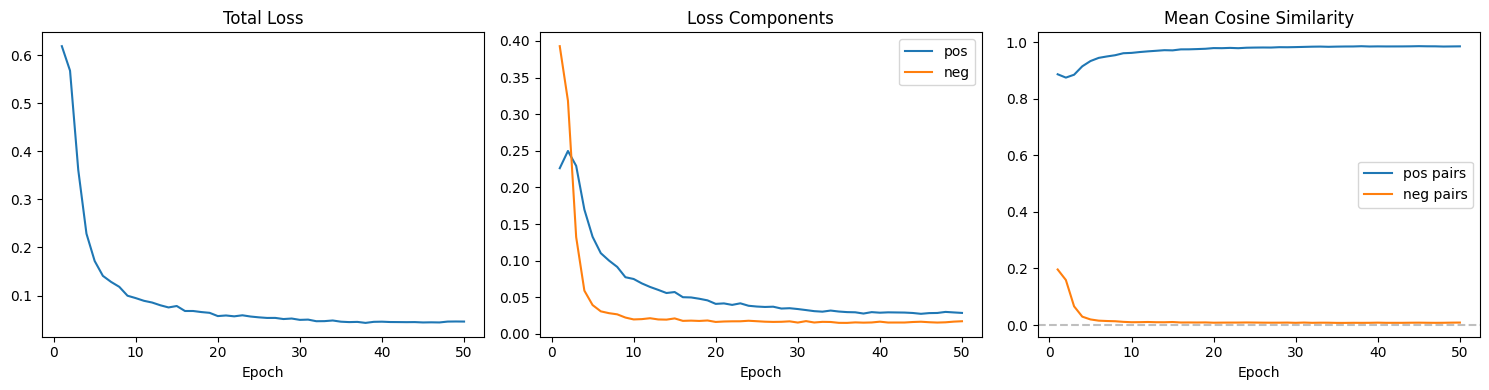


Done. Best loss: 0.0430  |  Outputs: /content/drive/MyDrive/echonet_project/optical_flow_encoder


In [ ]:
def run_train_step(batch_frames, enc, optimizer, scaler, is_last):
    B, C, pairs, ch, H, W = batch_frames.shape
    if torch.isnan(batch_frames).any():
        return float('nan'), {}

    frames_flat = batch_frames.view(B * C * pairs, ch, H, W).to(DEVICE)

    with torch.autocast(device_type=DEVICE.type, enabled=(AMP and DEVICE.type == 'cuda')):
        emb_flat = enc(frames_flat)
        if torch.isnan(emb_flat).any():
            optimizer.zero_grad(set_to_none=True)
            return float('nan'), {}
        emb  = emb_flat.view(B, C, pairs, 512)
        loss, comp = cardiac_contrastive_loss(emb)
        loss = loss / ACCUM_STEPS

    scaler.scale(loss).backward()

    if is_last:
        scaler.unscale_(enc.parameters() if False else optimizer)
        grad_norm = torch.nn.utils.clip_grad_norm_(enc.parameters(), 1.0)
        comp['grad_norm'] = grad_norm.item()
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

    return loss.item() * ACCUM_STEPS, comp


def train(train_df, val_df):
    out = DRIVE_OUT
    out.mkdir(parents=True, exist_ok=True)

    # Resume detection
    resume_epoch, resume_ckpt = 0, None
    existing = sorted(out.glob('encoder_epoch_*.pt'))
    if existing:
        resume_ckpt  = existing[-1]
        resume_epoch = int(resume_ckpt.stem.split('_')[-1])
        print(f"Resuming from epoch {resume_epoch}")
    else:
        print("Starting from scratch")

    print("Building dataset...")
    train_ds      = EchoFlowContrastiveDataset(train_df)
    train_sampler = CardiacBatchSampler(train_ds)
    train_loader  = DataLoader(train_ds, batch_sampler=train_sampler,
                               num_workers=8, pin_memory=True)

    enc       = build_encoder().to(DEVICE)
    optimizer = AdamW(enc.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scaler    = torch.amp.GradScaler(DEVICE.type, enabled=(AMP and DEVICE.type == 'cuda'))

    steps_per_epoch = max(len(train_loader) // ACCUM_STEPS, 1)
    total_steps     = steps_per_epoch * EPOCHS
    scheduler = OneCycleLR(optimizer, max_lr=LR, total_steps=total_steps,
                           pct_start=0.05, last_epoch=-1)

    history, best_loss = [], float('inf')

    if resume_ckpt:
        ckpt = torch.load(resume_ckpt, map_location=DEVICE)
        enc.load_state_dict(ckpt['encoder'])
        optimizer.load_state_dict(ckpt['optimizer'])
        scheduler.load_state_dict(ckpt['scheduler'])
        scaler.load_state_dict(ckpt['scaler'])
        history   = ckpt.get('history', [])
        best_loss = min((h['loss'] for h in history), default=float('inf'))
        print(f"Restored. Best loss so far: {best_loss:.4f}")

    print(f"\nTraining {EPOCHS} epochs | {len(train_loader)} batches/epoch")

    for epoch in range(resume_epoch + 1, EPOCHS + 1):
        t0 = time.time()
        train_ds.refresh_epoch()
        enc.train()
        optimizer.zero_grad(set_to_none=True)

        epoch_loss, epoch_comp, n_steps, opt_steps = 0.0, defaultdict(float), 0, 0

        for step, (batch_frames, _) in enumerate(
                tqdm(train_loader, desc=f'Epoch {epoch:03d}', leave=False), 1):

            is_last = (step % ACCUM_STEPS == 0) or (step == len(train_loader))
            loss, comp = run_train_step(batch_frames, enc, optimizer, scaler, is_last)

            if is_last:
                scheduler.step()
                opt_steps += 1

            if loss == loss:
                epoch_loss += loss
                for k, v in comp.items():
                    epoch_comp[k] += v
                n_steps += 1

            if is_last and opt_steps % LOG_EVERY_N_BATCHES == 0:
                print(f"  [step {opt_steps:4d}] loss={loss:.4f} | "
                      f"sim_pos={comp.get('sim_pos', float('nan')):.3f} | "
                      f"sim_neg={comp.get('sim_neg', float('nan')):.3f} | "
                      f"grad={comp.get('grad_norm', float('nan')):.3f}")

        n = max(n_steps, 1)
        epoch_loss /= n
        for k in epoch_comp: epoch_comp[k] /= n

        dt = time.time() - t0
        print(f"Epoch {epoch:03d} | loss={epoch_loss:.4f} | "
              f"sim_pos={epoch_comp['sim_pos']:.3f} | "
              f"sim_neg={epoch_comp['sim_neg']:.3f} | {dt:.1f}s")

        history.append({'epoch': epoch, 'loss': epoch_loss, **epoch_comp, 'secs': dt})

        ckpt = {
            'epoch': epoch, 'encoder': enc.state_dict(),
            'optimizer': optimizer.state_dict(), 'scheduler': scheduler.state_dict(),
            'scaler': scaler.state_dict(), 'loss': epoch_loss, 'history': history,
        }
        torch.save(ckpt, out / f'encoder_epoch_{epoch:03d}.pt')
        if epoch_loss < best_loss:
            best_loss = epoch_loss
            torch.save(ckpt, out / 'encoder_best.pt')
            print(f"  ✓ New best: {best_loss:.4f}")

    pd.DataFrame(history).to_csv(out / 'history.csv', index=False)

    hist = pd.DataFrame(history)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(hist['epoch'], hist['loss']); axes[0].set_title('Total Loss')
    axes[1].plot(hist['epoch'], hist['loss_pos'], label='pos')
    axes[1].plot(hist['epoch'], hist['loss_neg'], label='neg')
    axes[1].legend(); axes[1].set_title('Loss Components')
    axes[2].plot(hist['epoch'], hist['sim_pos'], label='pos pairs')
    axes[2].plot(hist['epoch'], hist['sim_neg'], label='neg pairs')
    axes[2].axhline(0, color='gray', linestyle='--', alpha=0.5)
    axes[2].legend(); axes[2].set_title('Mean Cosine Similarity')
    for ax in axes: ax.set_xlabel('Epoch')
    plt.tight_layout()
    plt.savefig(out / 'training_curves.png', dpi=100)
    plt.show()
    print(f"\nDone. Best loss: {best_loss:.4f}  |  Outputs: {out}")
    return enc


encoder = train(train_df, val_df)


## 11. Similarity Curve Computation

For each validation video, load the cached flow fields, encode every consecutive
pair, then compute mean cosine similarity between embeddings at each lag τ.
The curve should peak at multiples of T if the encoder has learned periodicity.


In [ ]:
@torch.no_grad()
def compute_similarity_curve(encoder, video_path, n_frames, fps, max_lag=None):
    encoder.eval()

    try:
        flow_array = load_flow_cache(video_path)   # (N-1, H, W, 2)
    except Exception as e:
        print(f"Cache load failed: {e}")
        return None, None

    # Normalise and tensorise all flow fields
    flow_tensors = []
    for i in range(len(flow_array)):
        f = flow_array[i].astype(np.float32)
        mean, std = f.mean(), f.std() + 1e-6
        f = (f - mean) / std
        flow_tensors.append(torch.from_numpy(f).permute(2, 0, 1))   # (2, H, W)

    flow_stack = torch.stack(flow_tensors).to(DEVICE)   # (N-1, 2, H, W)

    embs = []
    with torch.autocast(device_type=DEVICE.type, enabled=(AMP and DEVICE.type == 'cuda')):
        for i in range(0, len(flow_stack), 32):
            e = encoder(flow_stack[i:i+32])
            embs.append(F.normalize(e, dim=-1).cpu())
    embs = torch.cat(embs, dim=0)   # (N-1, 512)

    if max_lag is None:
        min_lag_f = max(1, int(fps / (MAX_BPM / 60)))
        max_lag_f = int(fps / (MIN_BPM / 60))
        max_lag   = min(max_lag_f * 3, len(embs) - 1)

    lags = list(range(1, max_lag + 1))
    sims = [(embs[:-lag] * embs[lag:]).sum(dim=-1).mean().item() for lag in lags]
    return np.array(lags), np.array(sims)


## 12. HR Estimation Methods

In [ ]:
def get_lag_bounds(fps):
    return max(1, int(fps / (MAX_BPM / 60))), int(fps / (MIN_BPM / 60))

def restrict_physiological(lags, sims, fps):
    min_lag, max_lag = get_lag_bounds(fps)
    mask = (lags >= min_lag) & (lags <= max_lag)
    return lags[mask], sims[mask]

def lag_to_bpm(lag, fps):
    return fps / lag * 60

def method_naive(lags, sims, fps):
    l, s = restrict_physiological(lags, sims, fps)
    if len(l) == 0: return None
    return lag_to_bpm(l[np.argmax(s)], fps)

def method_peak_spacing(lags, sims, fps):
    min_lag, _ = get_lag_bounds(fps)
    prominence = max(PEAK_PROMINENCE * (sims.max() - sims.min()), 1e-6)
    peak_idxs, _ = find_peaks(sims, prominence=prominence, distance=min_lag)
    peak_lags = lags[peak_idxs]
    peak_lags = peak_lags[peak_lags >= min_lag]
    if len(peak_lags) < 2: return method_naive(lags, sims, fps)
    return float(np.clip(lag_to_bpm(np.mean(np.diff(peak_lags)), fps), MIN_BPM, MAX_BPM))

def method_hps(lags, sims, fps):
    N_fft     = len(sims) * 4
    spec      = np.abs(np.fft.rfft(sims, n=N_fft))
    freqs_bpm = np.fft.rfftfreq(N_fft, d=1.0) * fps * 60
    phys_mask = (freqs_bpm >= MIN_BPM) & (freqs_bpm <= MAX_BPM)
    hps = spec.copy()
    for h in range(2, HPS_HARMONICS + 1):
        down = spec[::h]; min_len = min(len(hps), len(down))
        hps[:min_len] *= down[:min_len]
    hps_phys = hps.copy(); hps_phys[~phys_mask] = 0
    if hps_phys.max() == 0: return method_naive(lags, sims, fps)
    return float(freqs_bpm[np.argmax(hps_phys)])

def method_harmonic_verify(lags, sims, fps):
    min_lag, max_lag = get_lag_bounds(fps)
    prominence = max(PEAK_PROMINENCE * (sims.max() - sims.min()), 1e-6)
    peak_idxs, _ = find_peaks(sims, prominence=prominence, distance=min_lag)
    peak_lags    = lags[peak_idxs]
    phys_peaks   = peak_lags[(peak_lags >= min_lag) & (peak_lags <= max_lag)]
    if len(phys_peaks) == 0: return method_naive(lags, sims, fps)

    def peak_near(target):
        tol = HARMONIC_TOL * target
        return any(abs(p - target) <= tol for p in peak_lags)

    def score(T_cand):
        return sum(peak_near(k * T_cand) for k in [2, 3])

    best_T, best_score = phys_peaks[0], -1
    for T_cand in phys_peaks:
        s = score(T_cand)
        if s > best_score: best_score, best_T = s, T_cand

    if best_score == 0:
        half = best_T / 2
        if half >= min_lag and score(half) > 0 and peak_near(half):
            best_T = half

    return float(np.clip(lag_to_bpm(best_T, fps), MIN_BPM, MAX_BPM))

METHODS = {
    'Naive First Peak'      : method_naive,
    'Peak Spacing'          : method_peak_spacing,
    'Harmonic Product Spec' : method_hps,
    'Harmonic Verify'       : method_harmonic_verify,
}
print(f"Defined {len(METHODS)} estimation methods.")


Defined 4 estimation methods.


## 13. Validation Evaluation

In [ ]:
best_ckpt = torch.load(DRIVE_OUT / 'encoder_best.pt', map_location=DEVICE)
eval_enc  = build_encoder().to(DEVICE)
eval_enc.load_state_dict(best_ckpt['encoder'])
eval_enc.eval()
print(f"Loaded encoder from epoch {best_ckpt['epoch']} (loss={best_ckpt['loss']:.4f})")

print("\nComputing similarity curves...")
val_curves = {}
for _, row in tqdm(val_df.iterrows(), total=len(val_df)):
    lags, sims = compute_similarity_curve(
        eval_enc, row['video_path'],
        n_frames=int(row['n_frames']), fps=float(row['fps']),
    )
    if lags is not None:
        val_curves[row['video_path']] = (lags, sims, float(row['fps']))
print(f"Curves computed for {len(val_curves)}/{len(val_df)} videos")


ResNet-18 (2-ch flow): 11,173,376 params
Loaded encoder from epoch 38 (loss=0.0430)

Computing similarity curves...


  0%|          | 0/72 [00:00<?, ?it/s]

Curves computed for 72/72 videos


In [ ]:
def is_harmonic_error(est, true, thresh=HARMONIC_THRESH_BPM, max_k=4):
    if abs(est - true) <= thresh: return False
    for k in range(2, max_k + 1):
        if abs(est - k * true) <= thresh or abs(est - true / k) <= thresh:
            return True
    return False


def evaluate_all_methods(val_df, val_curves):
    results = {}
    for name, fn in METHODS.items():
        records = []
        for _, row in val_df.iterrows():
            entry = val_curves.get(row['video_path'])
            if entry is None: continue
            lags, sims, fps = entry
            est = fn(lags, sims, fps)
            if est is None: continue
            true_bpm = float(row['heart_rate'])
            records.append({
                'video_path'     : row['video_path'],
                'true_bpm'       : true_bpm,
                'est_bpm'        : est,
                'abs_err'        : abs(est - true_bpm),
                'pct_err'        : abs(est - true_bpm) / true_bpm * 100,
                'harmonic_error' : is_harmonic_error(est, true_bpm),
            })
        results[name] = pd.DataFrame(records)
    return results


results = evaluate_all_methods(val_df, val_curves)

rows = []
for name, df in results.items():
    if len(df) == 0: continue
    rows.append({
        'Method'              : name,
        'N'                   : len(df),
        'MAE (BPM)'           : df['abs_err'].mean(),
        'Median AE (BPM)'     : df['abs_err'].median(),
        'P90 AE (BPM)'        : df['abs_err'].quantile(0.90),
        'MAPE (%)'            : df['pct_err'].mean(),
        'Harmonic Error Rate' : df['harmonic_error'].mean() * 100,
    })

summary = pd.DataFrame(rows).set_index('Method')
pd.set_option('display.float_format', '{:.2f}'.format)
print("\n" + "=" * 65)
print("METHOD COMPARISON — VALIDATION SET")
print("=" * 65)
print(summary.to_string())
print("=" * 65)
summary.to_csv(DRIVE_OUT / 'val_metrics_summary.csv')
print(f"Saved → {DRIVE_OUT / 'val_metrics_summary.csv'}")



METHOD COMPARISON — VALIDATION SET
                        N  MAE (BPM)  Median AE (BPM)  P90 AE (BPM)  MAPE (%)  Harmonic Error Rate
Method                                                                                            
Naive First Peak       72      17.14             6.94         39.79     23.31                38.89
Peak Spacing           72      16.40             3.89         54.00     25.49                 1.39
Harmonic Product Spec  72      25.82            31.09         49.81     34.30                44.44
Harmonic Verify        72       4.07             0.96          8.02      6.08                 1.39
Saved → /content/drive/MyDrive/echonet_project/optical_flow_encoder/val_metrics_summary.csv


## 14. Visualisation

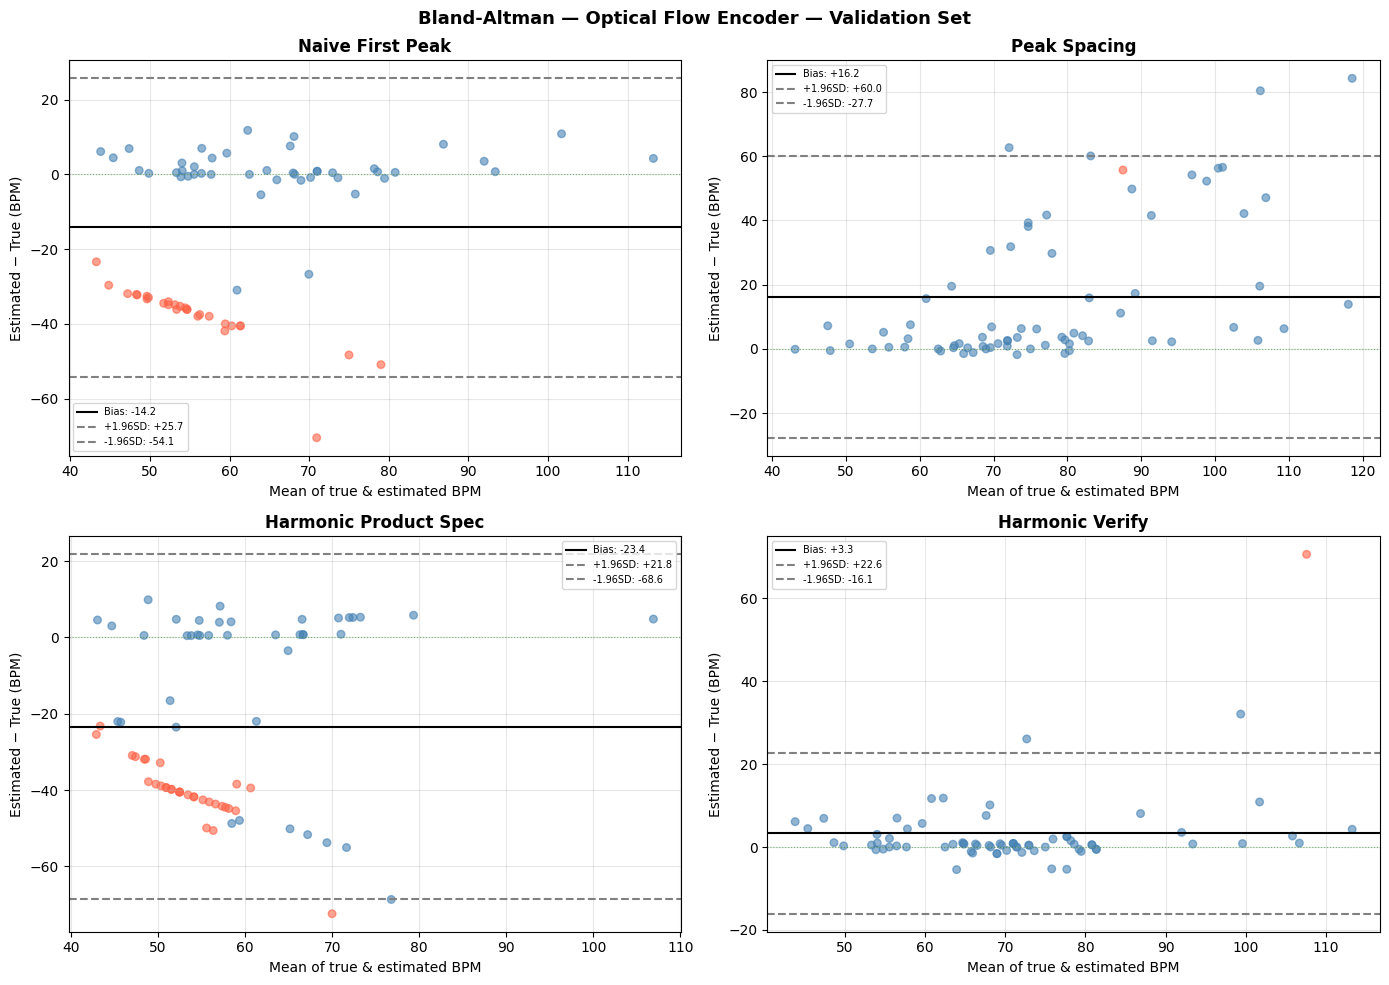

/tmp/ipykernel_921/2953903346.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([df['abs_err'].values for df in results.values()],


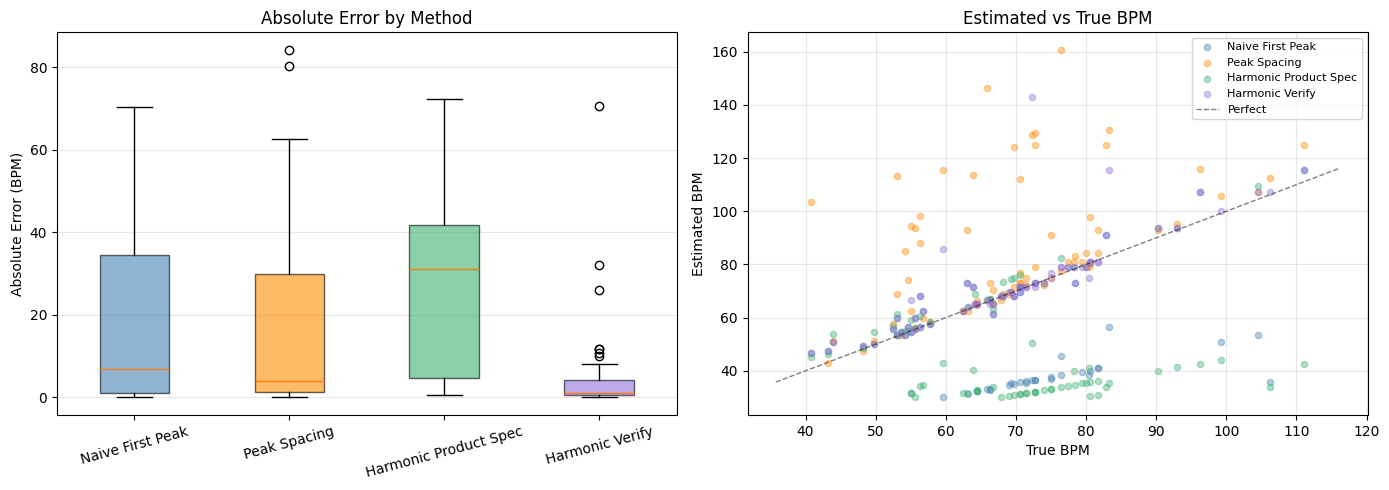

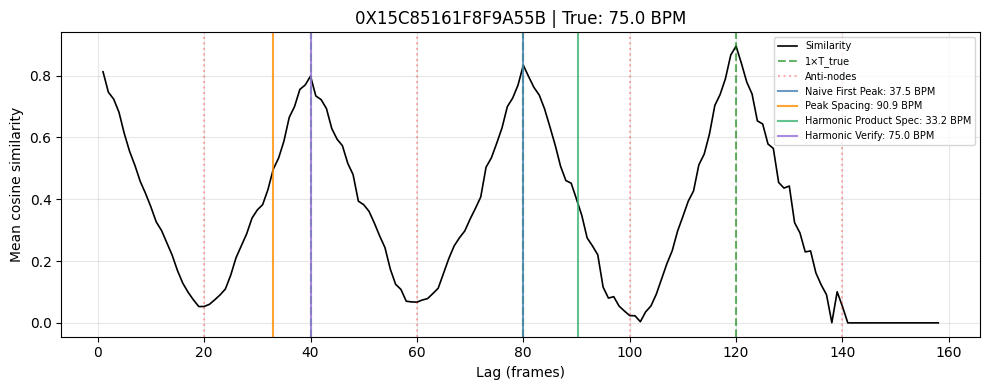

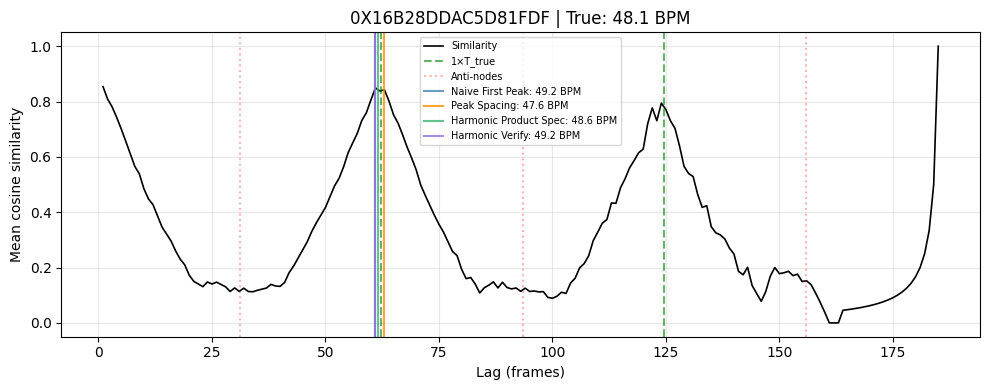

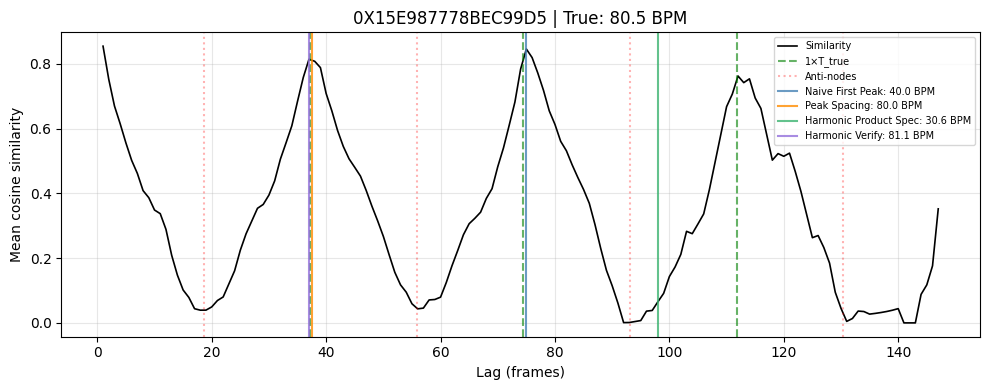

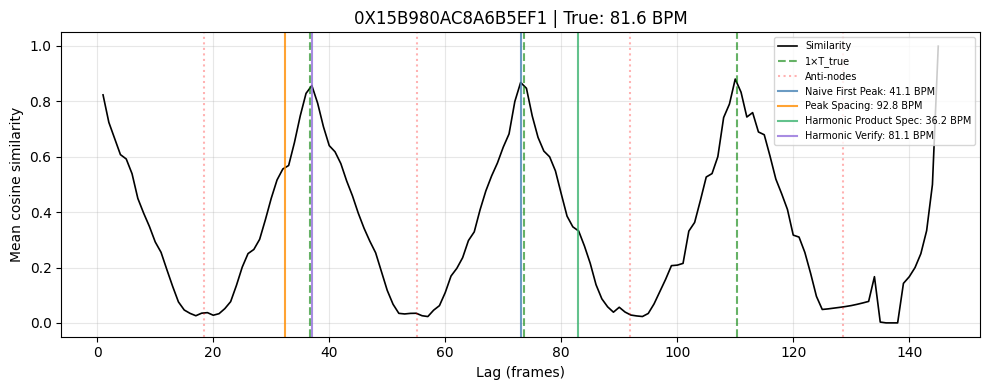

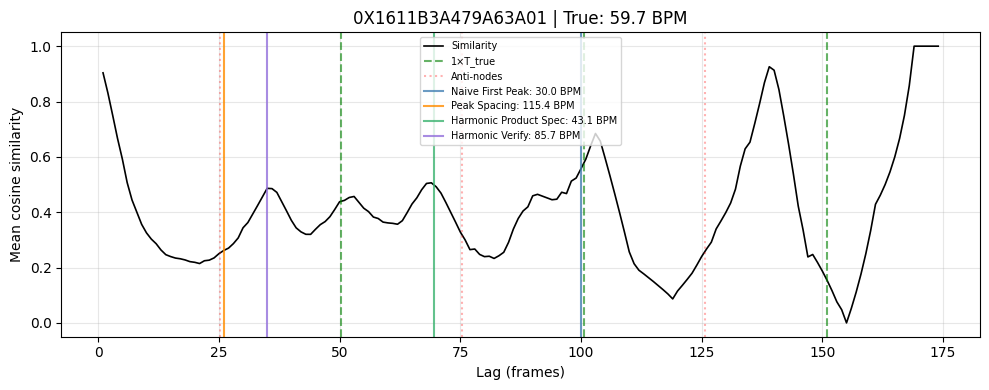

All plots saved to /content/drive/MyDrive/echonet_project/optical_flow_encoder/val_plots


In [ ]:
VAL_PLOTS = DRIVE_OUT / 'val_plots'
VAL_PLOTS.mkdir(parents=True, exist_ok=True)
colors_box = ['steelblue', 'darkorange', 'mediumseagreen', 'mediumpurple']

# ── Bland-Altman ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for ax, (name, df) in zip(axes, results.items()):
    if len(df) == 0: ax.set_visible(False); continue
    mean_val = (df['true_bpm'] + df['est_bpm']) / 2
    diff_val = df['est_bpm'] - df['true_bpm']
    bias, sd = diff_val.mean(), diff_val.std()
    ax.scatter(mean_val, diff_val,
               c=np.where(df['harmonic_error'], 'tomato', 'steelblue'),
               alpha=0.6, s=30)
    ax.axhline(bias,             color='black', linewidth=1.5, label=f'Bias: {bias:+.1f}')
    ax.axhline(bias + 1.96 * sd, color='gray',  linestyle='--', label=f'+1.96SD: {bias+1.96*sd:+.1f}')
    ax.axhline(bias - 1.96 * sd, color='gray',  linestyle='--', label=f'-1.96SD: {bias-1.96*sd:+.1f}')
    ax.axhline(0, color='green', linewidth=0.8, linestyle=':', alpha=0.5)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Mean of true & estimated BPM')
    ax.set_ylabel('Estimated − True (BPM)')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
fig.suptitle('Bland-Altman — Optical Flow Encoder — Validation Set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(VAL_PLOTS / 'bland_altman.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Error distributions ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
bp = ax.boxplot([df['abs_err'].values for df in results.values()],
                labels=list(METHODS.keys()), patch_artist=True)
for patch, col in zip(bp['boxes'], colors_box):
    patch.set_facecolor(col); patch.set_alpha(0.6)
ax.set_ylabel('Absolute Error (BPM)')
ax.set_title('Absolute Error by Method')
ax.tick_params(axis='x', rotation=15); ax.grid(True, axis='y', alpha=0.3)

ax = axes[1]
for (name, df), col in zip(results.items(), colors_box):
    ax.scatter(df['true_bpm'], df['est_bpm'], alpha=0.4, s=20, label=name, color=col)
all_bpm = np.concatenate([df['true_bpm'].values for df in results.values()])
lo, hi  = all_bpm.min() - 5, all_bpm.max() + 5
ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1, alpha=0.5, label='Perfect')
ax.set_xlabel('True BPM'); ax.set_ylabel('Estimated BPM')
ax.set_title('Estimated vs True BPM')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(VAL_PLOTS / 'error_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Sample similarity curves ──────────────────────────────────────────────────
for _, row in val_df.sample(min(5, len(val_df)), random_state=SEED).iterrows():
    entry = val_curves.get(row['video_path'])
    if entry is None: continue
    lags, sims, fps = entry
    T_true = fps / (float(row['heart_rate']) / 60)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(lags, sims, color='black', linewidth=1.2, label='Similarity')
    for k in range(1, 4):
        xv = k * T_true
        if xv <= lags[-1]:
            ax.axvline(xv, color='green', linestyle='--', alpha=0.6,
                       label=f'{k}×T_true' if k == 1 else None)
    for k in range(1, 6):
        xv = (k - 0.5) * T_true
        if xv <= lags[-1]:
            ax.axvline(xv, color='red', linestyle=':', alpha=0.3,
                       label='Anti-nodes' if k == 1 else None)
    for (name, fn), col in zip(METHODS.items(), colors_box):
        est = fn(lags, sims, fps)
        if est:
            ax.axvline(fps / (est / 60), color=col, linewidth=1.5, alpha=0.8,
                       label=f'{name}: {est:.1f} BPM')
    ax.set_title(f"{Path(row['video_path']).stem} | True: {row['heart_rate']:.1f} BPM")
    ax.set_xlabel('Lag (frames)'); ax.set_ylabel('Mean cosine similarity')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(VAL_PLOTS / f"curve_{Path(row['video_path']).stem[:30]}.png",
                dpi=120, bbox_inches='tight')
    plt.show(); plt.close()

print(f"All plots saved to {VAL_PLOTS}")


## 15. Final Summary

In [ ]:
print("\n" + "=" * 65)
print("FINAL SUMMARY — OPTICAL FLOW ENCODER — VALIDATION SET")
print("=" * 65)
print(summary.to_string())
print("=" * 65)
print(f"\nBest MAE:            {summary['MAE (BPM)'].idxmin()} — {summary['MAE (BPM)'].min():.2f} BPM")
print(f"Lowest harmonic err: {summary['Harmonic Error Rate'].idxmin()} — {summary['Harmonic Error Rate'].min():.1f}%")
print(f"\nAll outputs in: {DRIVE_OUT}")



FINAL SUMMARY — OPTICAL FLOW ENCODER — VALIDATION SET
                        N  MAE (BPM)  Median AE (BPM)  P90 AE (BPM)  MAPE (%)  Harmonic Error Rate
Method                                                                                            
Naive First Peak       72      17.14             6.94         39.79     23.31                38.89
Peak Spacing           72      16.40             3.89         54.00     25.49                 1.39
Harmonic Product Spec  72      25.82            31.09         49.81     34.30                44.44
Harmonic Verify        72       4.07             0.96          8.02      6.08                 1.39

Best MAE:            Harmonic Verify — 4.07 BPM
Lowest harmonic err: Peak Spacing — 1.4%

All outputs in: /content/drive/MyDrive/echonet_project/optical_flow_encoder
